<a href="https://colab.research.google.com/github/gyuhyeongkim412-creator/financial-data-bootcamp/blob/main/%ED%80%80%ED%8A%B8_%EB%B0%B1%ED%85%8C%EC%8A%A4%ED%8C%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 프로젝트
## **03: 멀티에이전트 퀀트 백테스팅 시스템**

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LinearRegression

tickers = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']

# Fix: ['Close'] must be on the same line (or use a backslash continuation)
data = yf.download(tickers + ['SPY'], start='2020-01-01', progress=False)['Close']
rets = data.pct_change().dropna()

market = rets['SPY'].values.reshape(-1, 1)
print(f"{'종목':<6} {'Beta':>6} {'R²':>6} {'체계적':>8} {'비체계적':>8}")
print("-" * 40)

for t in tickers:
    stock = rets[t].values
    reg = LinearRegression().fit(market, stock)
    beta = reg.coef_[0]
    r2 = reg.score(market, stock)
    # Fix: print() was outside the loop due to missing indentation
    print(f"{t:<6} {beta:>6.2f} {r2:>6.2f} {r2:>7.1%} {1-r2:>7.1%}")

/tmp/ipykernel_167/220021000.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers + ['SPY'], start='2020-01-01', progress=False)['Close']


종목       Beta     R²      체계적     비체계적
----------------------------------------
AAPL     1.20   0.61   60.7%   39.3%
MSFT     1.14   0.62   62.3%   37.7%
JPM      1.08   0.50   49.9%   50.1%
XOM      0.79   0.25   24.5%   75.5%
JNJ      0.42   0.19   19.0%   81.0%


/tmp/ipykernel_167/647161391.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start='2020-01-01', progress=False)['Close']


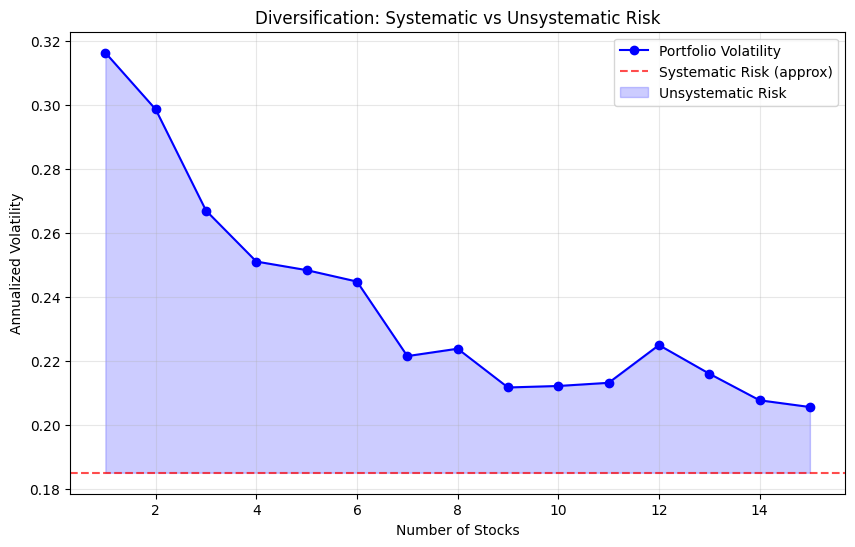

In [ ]:
import matplotlib.pyplot as plt

all_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM',
               'BAC', 'XOM', 'CVX', 'JNJ', 'PFE',
               'PG', 'KO', 'DIS', 'NFLX', 'NVDA']

# Fix 1: ['Close'] on the same line
data = yf.download(all_tickers, start='2020-01-01', progress=False)['Close']
rets = data.pct_change().dropna()

portfolio_vols = []

# Fix 2: indent the loop body
for n in range(1, len(all_tickers) + 1):
    selected = rets.iloc[:, :n]
    w = np.ones(n) / n
    port_ret = selected @ w
    vol = port_ret.std() * np.sqrt(252)
    portfolio_vols.append(vol)

market_vol = rets.mean(axis=1).std() * np.sqrt(252) * 0.9

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(all_tickers)+1), portfolio_vols, 'bo-',
         label='Portfolio Volatility')
plt.axhline(market_vol, color='red', linestyle='--',
            label='Systematic Risk (approx)', alpha=0.7)
plt.fill_between(range(1, len(all_tickers)+1), portfolio_vols, market_vol,
                 alpha=0.2, color='blue', label='Unsystematic Risk')
plt.xlabel('Number of Stocks')
plt.ylabel('Annualized Volatility')
plt.title('Diversification: Systematic vs Unsystematic Risk')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

P12_Emotion_Journey_EN.png


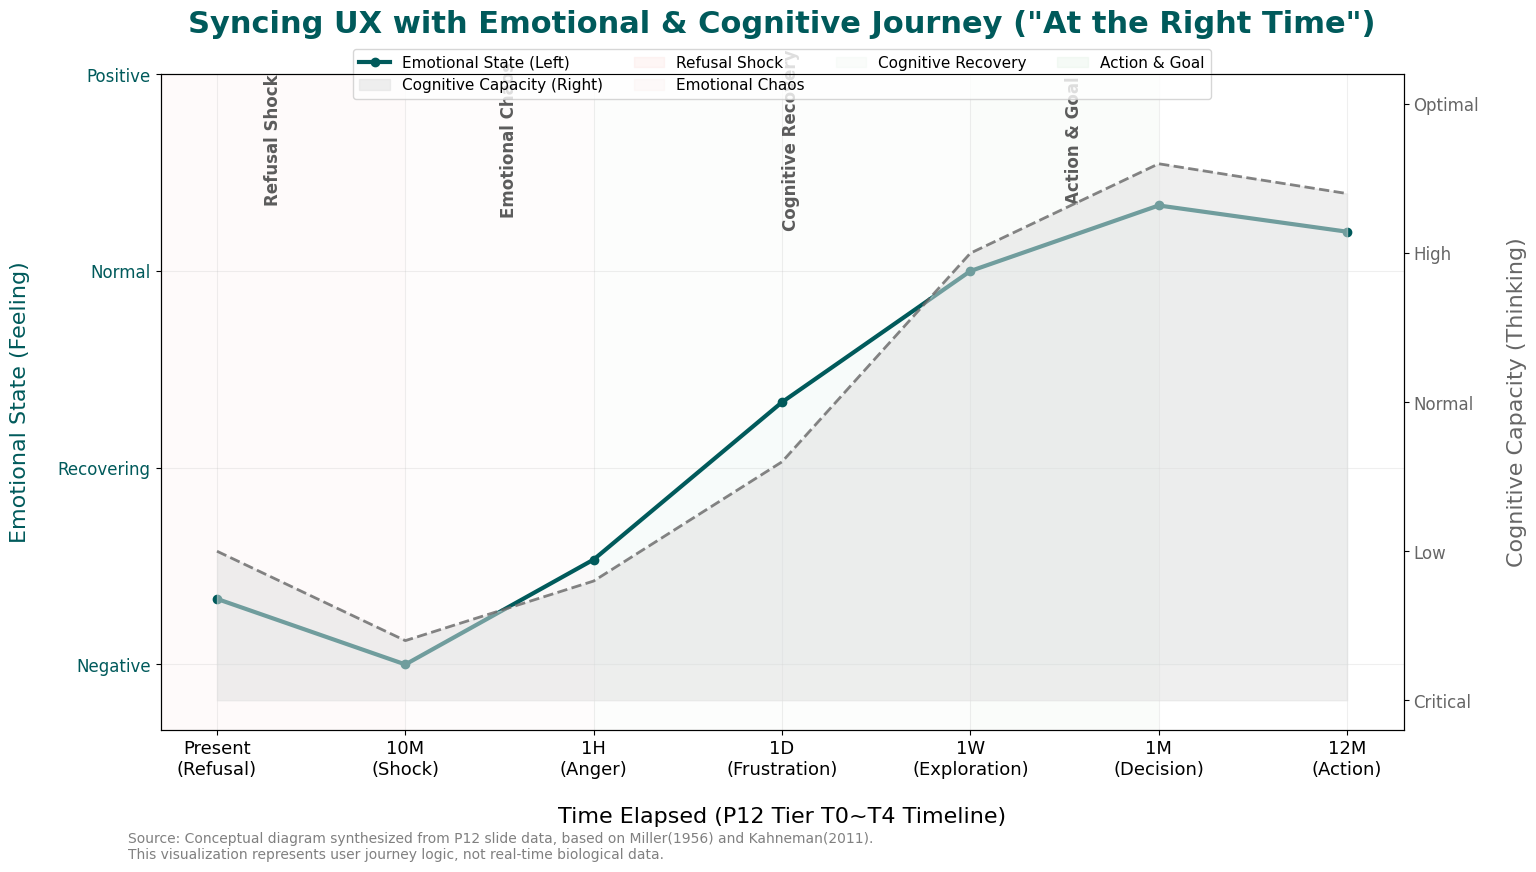

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as patches

# 데이터: 감정 곡선 (UX Emotion Journey)
# X축: 시간 (Present (Refusal) / 10M / 1H / 1D / 1W / 1M / 12M)
times = np.array([0, 10, 60, 1440, 10080, 43200, 518400]) # minute 단위
# 로그 스케일 시각화를 위한 가짜 X축 (순서형)
x_labels = np.array([0, 1, 2, 3, 4, 5, 6])

# Y축: 감정 상태 (Positive / Normal / Negative)
# Refusal Shock (T=0) -> Lowest -> Recovery -> Adaptation
emotion_scores = np.array([-2.5, -3.0, -2.2, -1.0, 0.0, 0.5, 0.3]) # -3 to +3 스케일

# Y축: 인지 능력 (Cognitive Load Capacity)
# Refusal Shock -> Lowest -> Slow Recovery -> High
cognitive_scores = np.array([0.5, 0.2, 0.4, 0.8, 1.5, 1.8, 1.7]) # 0 to 2 스케일

# --- UX Emotion & Cognitive Journey Chart ---
fig, ax1 = plt.subplots(figsize=(16, 9))

# Colors
teal_dark = '#005a5b'
teal_mid = '#008485'
teal_light = '#f0f8f8'
red_negative = '#D93025'
gray_soft = '#E0E0E0'

# Plot 1: Emotional State (Line + Shade, left axis)
ax1.plot(x_labels, emotion_scores, color=teal_dark, linewidth=3, marker='o', label='Emotional State (Left)')
ax1.fill_between(x_labels, emotion_scores, -3, color=teal_light, alpha=0.3)

# Plot 2: Cognitive Load Capacity (Area chart, right axis)
ax2 = ax1.twinx()
ax2.fill_between(x_labels, cognitive_scores, color=gray_soft, alpha=0.5, label='Cognitive Capacity (Right)')
ax2.plot(x_labels, cognitive_scores, color='#666', linewidth=2, linestyle='--', alpha=0.8)

# Formatting axes
ax1.set_title('Syncing UX with Emotional & Cognitive Journey ("At the Right Time")', fontsize=22, fontweight='bold', pad=30, color=teal_dark)
ax1.set_xlabel('Time Elapsed (P12 Tier T0~T4 Timeline)', fontsize=16, labelpad=20)

# Left Axis (Emotion)
ax1.set_ylabel('Emotional State (Feeling)', fontsize=16, labelpad=20, color=teal_dark)
ax1.set_ylim(-3.5, 1.5)
ax1.set_yticks([-3, -1.5, 0, 1.5])
ax1.set_yticklabels(['Negative', 'Recovering', 'Normal', 'Positive'], fontsize=12, color=teal_dark)

# Right Axis (Cognitive)
ax2.set_ylabel('Cognitive Capacity (Thinking)', fontsize=16, labelpad=20, color='#666')
ax2.set_ylim(-0.1, 2.1)
ax2.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
ax2.set_yticklabels(['Critical', 'Low', 'Normal', 'High', 'Optimal'], fontsize=12, color='#666')

# X Axis (Time Labels - P12 Logic)
time_labels_full = ['Present\n(Refusal)', '10M\n(Shock)', '1H\n(Anger)', '1D\n( 좌절 )', '1W\n(탐색)', '1M\n(결심)', '12M\n(행동 유지)']
# 한국어가 섞여있어서 영어로 치환합니다.
time_labels_en = ['Present\n(Refusal)', '10M\n(Shock)', '1H\n(Anger)', '1D\n(Frustration)', '1W\n(Exploration)', '1M\n(Decision)', '12M\n(Action)']

ax1.set_xticks(x_labels)
ax1.set_xticklabels(time_labels_en, fontsize=13)

# Grid
ax1.grid(True, axis='both', linestyle='-', alpha=0.2)

# --- Vertical Phasing (P12 Logic) ---
phase_boundaries = [1, 2, 4, 5]
phase_colors = ['#FAD2D0', '#FCE8E6', '#E6F4EA', '#CEEAD6'] # Light red/green shades
phase_titles = ['Refusal Shock', 'Emotional Chaos', 'Cognitive Recovery', 'Action & Goal']

# Create custom legend handles for phase coloring
phase_patches = []

for i in range(len(phase_boundaries)):
    start_x = phase_boundaries[i-1] if i > 0 else -0.5
    end_x = phase_boundaries[i] if i < len(phase_boundaries) else 6.5

    # Shade background
    rect = patches.Rectangle((start_x, -3.5), end_x - start_x, 5.0, linewidth=0, facecolor=phase_colors[i], alpha=0.1)
    ax1.add_patch(rect)

    # Add phase titles
    mid_x = (start_x + end_x) / 2
    ax1.annotate(phase_titles[i], xy=(mid_x, 1.0), xytext=(0, 0), textcoords='offset points',
                ha='left', va='center', rotation=90, fontsize=12, color='#333', fontweight='bold', alpha=0.8)

    # Collect legend handle (colored rectangle)
    phase_patches.append(patches.Patch(color=phase_colors[i], alpha=0.2, label=phase_titles[i]))

# Collect all legend handles
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine legends and place below the title
ax1.legend(handles=handles1 + handles2 + phase_patches,
           labels=labels1 + labels2 + [p.get_label() for p in phase_patches],
           loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, fontsize=11, frameon=True)

# Footnote
plt.figtext(0.1, 0.01, 'Source: Conceptual diagram synthesized from P12 slide data, based on Miller(1956) and Kahneman(2011).\nThis visualization represents user journey logic, not real-time biological data.',
            fontsize=10, color='gray')

plt.tight_layout(pad=3.0)
plot_path = 'P12_Emotion_Journey_EN.png'
plt.savefig(plot_path)

print(plot_path)

In [ ]:

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
# =============================================================
# 1. Fama-French 팩터 데이터 다운로드
# =============================================================
import pandas_datareader.data as web
# Kenneth French Data Library에서 일별 팩터 데이터
ff3 = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench',
start='2020-01-01')[0]
ff3 = ff3 / 100 # 퍼센트 → 소수
# =============================================================
# 2. 종목 데이터
# =============================================================
stock = yf.download('AAPL', start='2020-01-01', progress=False)['Close']
stock_ret = stock.pct_change().dropna()
# 인덱스 맞추기
merged = pd.merge(stock_ret, ff3, left_index=True, right_index=True,
how='inner')
merged.columns = ['Ri', 'Mkt-RF', 'SMB', 'HML', 'RF']
merged['Ri_excess'] = merged['Ri'] - merged['RF'] # 초과수익률
# =============================================================
# 3. OLS 회귀분석
# =============================================================
X = merged[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X) # 절편(alpha) 추가
y = merged['Ri_excess']
model = sm.OLS(y, X).fit()
print(model.summary()

SyntaxError: incomplete input (692789682.py, line 30)

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import pandas_datareader.data as web

# 1. Fama-French 팩터 데이터
ff3 = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench',
                     start='2020-01-01')[0]
ff3 = ff3 / 100

# 2. 종목 데이터
stock = yf.download('AAPL', start='2020-01-01', progress=False)['Close']
stock_ret = stock.pct_change().dropna()

# 인덱스 맞추기
merged = pd.merge(stock_ret, ff3, left_index=True, right_index=True, how='inner')
merged.columns = ['Ri', 'Mkt-RF', 'SMB', 'HML', 'RF']
merged['Ri_excess'] = merged['Ri'] - merged['RF']

# 3. OLS 회귀분석
X = merged[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = merged['Ri_excess']

model = sm.OLS(y, X).fit()
print(model.summary())  # Fix: was print(model.summary()

/tmp/ipykernel_167/174971787.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff3 = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench',
/tmp/ipykernel_167/174971787.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download('AAPL', start='2020-01-01', progress=False)['Close']


                            OLS Regression Results                            
Dep. Variable:              Ri_excess   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     939.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        04:28:16   Log-Likelihood:                 4610.1
No. Observations:                1527   AIC:                            -9212.
Df Residuals:                    1523   BIC:                            -9191.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      0.962      0.3